In [3]:
!rm -f outputs/results/*
!rm -f figures/*.pdf
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.84 | fit_out=  99.84 | AUCsum=  5990.4 | AUCmean=  99.84 | AUCregret=     0.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  96.2 | maxG= 122.2 | sim_calls=2400
ga_rules     | best=  99.81 | fit_out=  99.81 | AUCsum=  5987.6 | AUCmean=  99.79 | AUCregret=     2.8 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  96.0 | maxG= 122.3 | sim_calls=2400
ga_surrogate | best=  99.81 | fit_out=  99.81 | AUCsum=  5987.0 | AUCmean=  99.78 | AUCregret=     3.5 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  90.7 | maxG= 128.0 | dataset=1280 | sim_calls=1280
hybrid       | best=  99.80 | fit_out=  99.80 | AUCsum=  5987.1 | AUCmean=  99.78 | AUCregret=     3.4 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  87.8 | maxG= 121.8 | dataset=1280 | sim_calls=1280

=== Running scenario: S2_ramadan ===
ga_only      | best=  99.71 | fit_out=  99.71 | AUCsum=  5979.6 | AUCmean=  99.66 | AUCregret=     3.2 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  88.1 | maxG= 126

In [2]:
# CELL 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_783/2799992553.py", line 5, in <cell line: 0>
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/Research/glycemic-hybrid-ga')
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py", line 342, in cd
    oldcwd = os.getcwd()

In [ ]:
# CELL 2 — Charger fichiers
import os

path = "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results"

files = sorted(os.listdir(path))

print("Number of files:", len(files))
files

Number of files: 21


['G_S1_normal_ga_only.npy',
 'G_S1_normal_ga_rules.npy',
 'G_S1_normal_ga_surrogate.npy',
 'G_S1_normal_hybrid.npy',
 'G_S2_ramadan_ga_only.npy',
 'G_S2_ramadan_ga_rules.npy',
 'G_S2_ramadan_ga_surrogate.npy',
 'G_S2_ramadan_hybrid.npy',
 'G_S3_stress_highcarb_ga_only.npy',
 'G_S3_stress_highcarb_ga_rules.npy',
 'G_S3_stress_highcarb_ga_surrogate.npy',
 'G_S3_stress_highcarb_hybrid.npy',
 'G_S4_exercise_lowcarb_ga_only.npy',
 'G_S4_exercise_lowcarb_ga_rules.npy',
 'G_S4_exercise_lowcarb_ga_surrogate.npy',
 'G_S4_exercise_lowcarb_hybrid.npy',
 'summary_S1_normal.csv',
 'summary_S2_ramadan.csv',
 'summary_S3_stress_highcarb.csv',
 'summary_S4_exercise_lowcarb.csv',
 'summary_all.csv']

In [ ]:
def compute_metrics(G):
    import numpy as np

    g = np.asarray(G)

    n = len(g)
    tir = 100.0 * np.sum((g >= 70) & (g <= 180)) / n
    tbr = 100.0 * np.sum(g < 70) / n
    tar = 100.0 * np.sum(g > 180) / n

    gmin = float(np.min(g))
    gmax = float(np.max(g))
    mean_g = float(np.mean(g))
    std_g = float(np.std(g))

    # NEW FITNESS
    fitness = tir - 2.0 * tbr - 0.5 * tar
    fitness -= 0.08 * abs(mean_g - 110)
    fitness -= 0.03 * std_g

    severe_hypo = int(gmin < 54)

    return tir, tbr, tar, gmin, gmax, mean_g, fitness, severe_hypo

In [ ]:
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.84 | fit_out=  99.84 | AUCsum=  5990.4 | AUCmean=  99.84 | AUCregret=     0.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  96.2 | maxG= 122.2 | sim_calls=2400
ga_rules     | best=  99.81 | fit_out=  99.81 | AUCsum=  5987.6 | AUCmean=  99.79 | AUCregret=     2.8 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  96.0 | maxG= 122.3 | sim_calls=2400
ga_surrogate | best=  99.81 | fit_out=  99.81 | AUCsum=  5987.0 | AUCmean=  99.78 | AUCregret=     3.5 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  90.7 | maxG= 128.0 | dataset=1280 | sim_calls=1280
hybrid       | best=  99.80 | fit_out=  99.80 | AUCsum=  5987.1 | AUCmean=  99.78 | AUCregret=     3.4 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  87.8 | maxG= 121.8 | dataset=1280 | sim_calls=1280

=== Running scenario: S2_ramadan ===
ga_only      | best=  99.71 | fit_out=  99.71 | AUCsum=  5979.6 | AUCmean=  99.66 | AUCregret=     3.2 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  88.1 | maxG= 126

In [ ]:
# CELL 4 — Parser noms fichiers
def extract_method(f):
    if "ga_only" in f:
        return "GA-only"
    elif "ga_rules" in f:
        return "GA+Rules"
    elif "ga_surrogate" in f:
        return "GA+Surrogate"
    elif "hybrid" in f:
        return "Hybrid"
    return "Unknown"


def extract_scenario(f):
    name = f.replace("G_", "").replace(".npy", "")
    for suffix in ["_ga_only", "_ga_rules", "_ga_surrogate", "_hybrid"]:
        name = name.replace(suffix, "")
    return name

In [ ]:
!rm -f outputs/results/*
!rm -f figures/*.pdf
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.79 | fit_out=  99.79 | AUCsum=  5983.3 | AUCmean=  99.72 | AUCregret=     5.5 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  92.3 | maxG= 125.4 | sim_calls=2400
ga_rules     | best=  99.79 | fit_out=  99.79 | AUCsum=  5983.6 | AUCmean=  99.73 | AUCregret=     5.2 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  99.9 | maxG= 123.8 | sim_calls=2400
ga_surrogate | best=  99.79 | fit_out=  99.79 | AUCsum=  5985.6 | AUCmean=  99.76 | AUCregret=     3.2 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  95.6 | maxG= 122.5 | dataset=1280 | sim_calls=1280
hybrid       | best=  99.81 | fit_out=  99.81 | AUCsum=  5984.5 | AUCmean=  99.74 | AUCregret=     4.3 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  95.8 | maxG= 122.1 | dataset=1280 | sim_calls=1280

=== Running scenario: S2_ramadan ===
ga_only      | best=  99.72 | fit_out=  99.72 | AUCsum=  5979.1 | AUCmean=  99.65 | AUCregret=     4.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  90.6 | maxG= 136

In [ ]:
# CELL 5 — Construire tableau complet
rows = []

npy_files = [f for f in files if f.endswith(".npy") and f.startswith("G_")]

print("NPY files found:", len(npy_files))
print(npy_files)

for f in npy_files:
    G = np.load(os.path.join(path, f))
    tir, tbr, tar, gmin, gmax, mean_g, fitness, severe_hypo = compute_metrics(G)

    rows.append({
        "Scenario": extract_scenario(f),
        "Method": extract_method(f),
        "Fitness": fitness,
        "TIR": tir,
        "TBR": tbr,
        "TAR": tar,
        "Gmin": gmin,
        "Gmax": gmax,
        "MeanG": mean_g,
        "SevereHypo": severe_hypo
    })

df = pd.DataFrame(rows)

if df.empty:
    print("No .npy trajectory files found. Check outputs/results.")
else:
    df = df.sort_values(["Scenario", "Method"])
    display(df)


NPY files found: 16
['G_S1_normal_ga_only.npy', 'G_S1_normal_ga_rules.npy', 'G_S1_normal_ga_surrogate.npy', 'G_S1_normal_hybrid.npy', 'G_S2_ramadan_ga_only.npy', 'G_S2_ramadan_ga_rules.npy', 'G_S2_ramadan_ga_surrogate.npy', 'G_S2_ramadan_hybrid.npy', 'G_S3_stress_highcarb_ga_only.npy', 'G_S3_stress_highcarb_ga_rules.npy', 'G_S3_stress_highcarb_ga_surrogate.npy', 'G_S3_stress_highcarb_hybrid.npy', 'G_S4_exercise_lowcarb_ga_only.npy', 'G_S4_exercise_lowcarb_ga_rules.npy', 'G_S4_exercise_lowcarb_ga_surrogate.npy', 'G_S4_exercise_lowcarb_hybrid.npy']


,Scenario,Method,Fitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,SevereHypo
1,S1_normal,GA+Rules,99.794828,100.0,0.0,0.0,99.883128,123.823838,110.908160,0
2,S1_normal,GA+Surrogate,99.792779,100.0,0.0,0.0,95.560417,122.453936,110.255035,0
0,S1_normal,GA-only,99.788230,100.0,0.0,0.0,92.265706,125.376961,109.591903,0
3,S1_normal,Hybrid,99.812962,100.0,0.0,0.0,95.804609,122.104966,109.925569,0
5,S2_ramadan,GA+Rules,99.677111,100.0,0.0,0.0,85.500602,140.910177,110.073651,0
6,S2_ramadan,GA+Surrogate,99.616375,100.0,0.0,0.0,81.644376,137.291941,109.649703,0
4,S2_ramadan,GA-only,99.718646,100.0,0.0,0.0,90.633997,136.354342,110.302457,0
7,S2_ramadan,Hybrid,99.663979,100.0,0.0,0.0,83.175240,140.041801,110.169560,0
9,S3_stress_highcarb,GA+Rules,99.532962,100.0,0.0,0.0,75.283411,145.144445,110.257375,0
10,S3_stress_highcarb,GA+Surrogate,99.496373,100.0,0.0,0.0,73.474366,150.405627,110.096920,0


In [ ]:
# CELL 6 — Tableau final paper
summary = df[[
    "Scenario",
    "Method",
    "Fitness",
    "TIR",
    "TBR",
    "TAR",
    "SevereHypo"
]]

summary

,Scenario,Method,Fitness,TIR,TBR,TAR,SevereHypo
1,S1_normal,GA+Rules,99.794828,100.0,0.0,0.0,0
2,S1_normal,GA+Surrogate,99.792779,100.0,0.0,0.0,0
0,S1_normal,GA-only,99.788230,100.0,0.0,0.0,0
3,S1_normal,Hybrid,99.812962,100.0,0.0,0.0,0
5,S2_ramadan,GA+Rules,99.677111,100.0,0.0,0.0,0
6,S2_ramadan,GA+Surrogate,99.616375,100.0,0.0,0.0,0
4,S2_ramadan,GA-only,99.718646,100.0,0.0,0.0,0
7,S2_ramadan,Hybrid,99.663979,100.0,0.0,0.0,0
9,S3_stress_highcarb,GA+Rules,99.532962,100.0,0.0,0.0,0
10,S3_stress_highcarb,GA+Surrogate,99.496373,100.0,0.0,0.0,0


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results/summary_all.csv")
df

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_783/3615815010.py", line 1, in <cell line: 0>
    df = pd.read_csv("/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results/summary_all.csv")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = sel

In [ ]:
# CELL 7 — Pivot table (super utile)
pivot = summary.pivot(index="Scenario", columns="Method", values="TIR")
pivot

Method,GA+Rules,GA+Surrogate,GA-only,Hybrid
Scenario,,,,
S1_normal,100.0,100.0,100.0,100.0
S2_ramadan,100.0,100.0,100.0,100.0
S3_stress_highcarb,100.0,100.0,100.0,100.0
S4_exercise_lowcarb,100.0,100.0,100.0,100.0


In [ ]:
# CELL 8 — Vérification sécurité
df[df["SevereHypo"] == 1]

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret


In [ ]:
#CELL 9 — Comparaison méthodes
df.groupby("Method")[["TIR","TBR","TAR","Fitness"]].mean()

,TIR,TBR,TAR,Fitness
Method,,,,
ga_only,100.0,0.0,0.0,99.523332
ga_rules,100.0,0.0,0.0,99.535863
ga_surrogate,100.0,0.0,0.0,99.571536
hybrid,100.0,0.0,0.0,99.424517


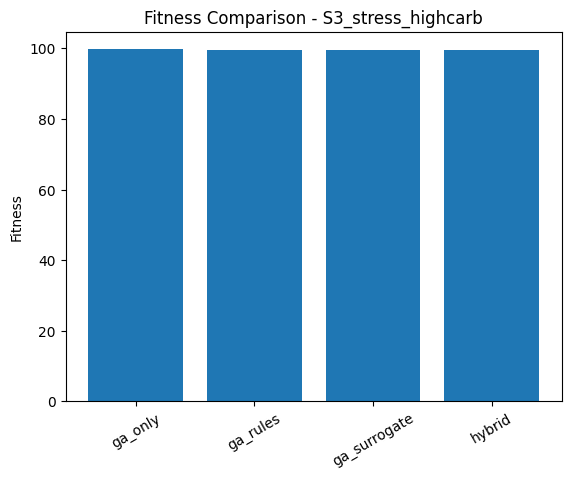

In [ ]:
import matplotlib.pyplot as plt

subset = df[df["Scenario"] == "S3_stress_highcarb"]

plt.figure()
plt.bar(subset["Method"], subset["Fitness"])
plt.title("Fitness Comparison - S3_stress_highcarb")
plt.ylabel("Fitness")
plt.xticks(rotation=30)
plt.show()

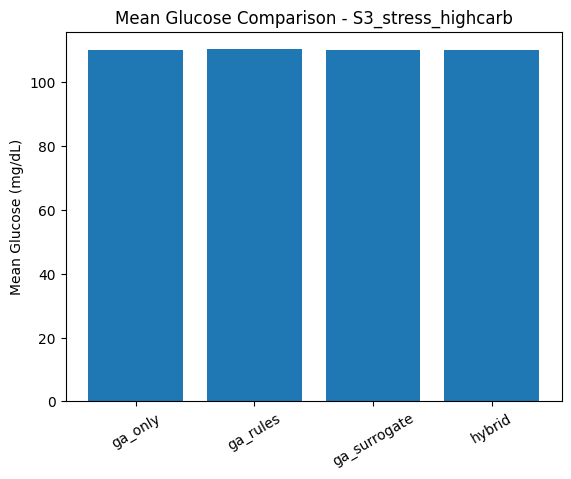

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["MeanG"])
plt.title("Mean Glucose Comparison - S3_stress_highcarb")
plt.ylabel("Mean Glucose (mg/dL)")
plt.xticks(rotation=30)
plt.show()

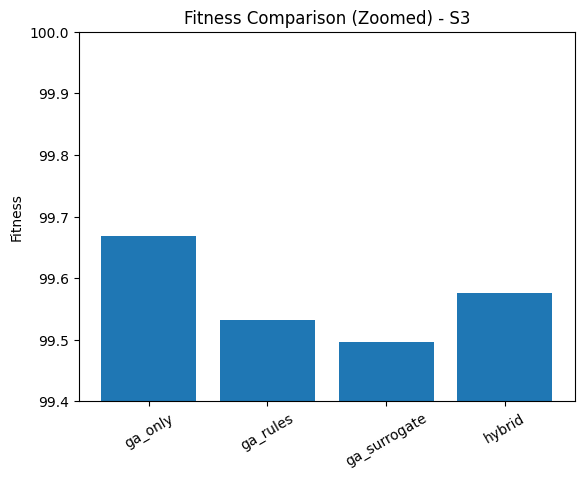

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["Fitness"])
plt.ylim(99.4, 100)   # 🔥 ZOOM
plt.title("Fitness Comparison (Zoomed) - S3")
plt.ylabel("Fitness")
plt.xticks(rotation=30)
plt.show()

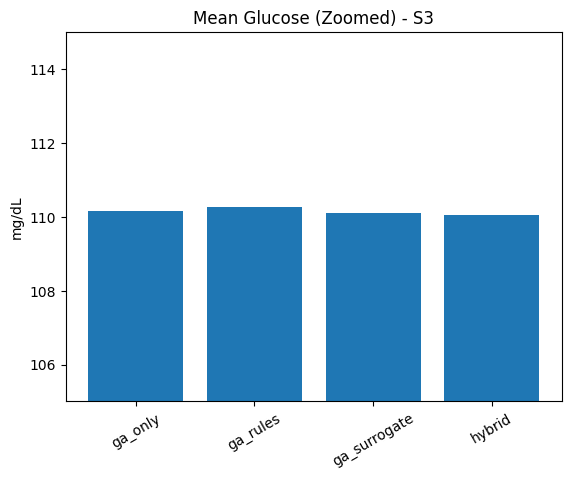

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["MeanG"])
plt.ylim(105, 115)   # 🔥 ZOOM
plt.title("Mean Glucose (Zoomed) - S3")
plt.ylabel("mg/dL")
plt.xticks(rotation=30)
plt.show()

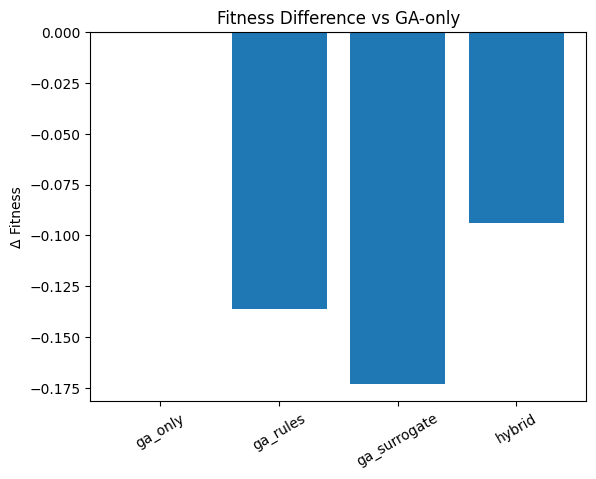

In [ ]:
baseline = subset[subset["Method"] == "ga_only"]["Fitness"].values[0]

subset = subset.copy()
subset["DeltaFitness"] = subset["Fitness"] - baseline

plt.figure()
plt.bar(subset["Method"], subset["DeltaFitness"])
plt.title("Fitness Difference vs GA-only")
plt.ylabel("Δ Fitness")
plt.xticks(rotation=30)
plt.axhline(0)
plt.show()



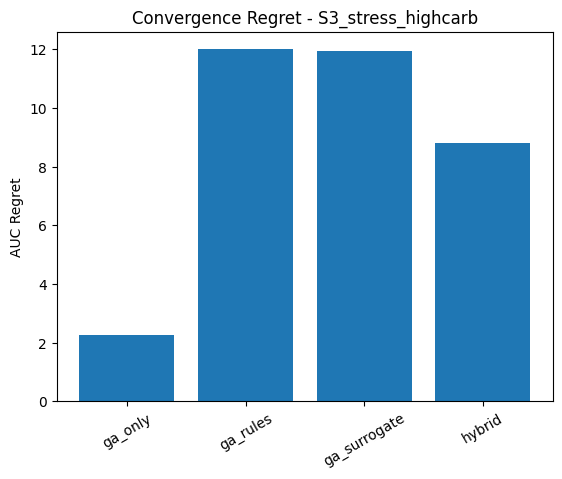

In [ ]:
df_csv = pd.read_csv(
    "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results/summary_all.csv"
)

subset = df_csv[df_csv["Scenario"] == "S3_stress_highcarb"].copy()

plt.figure()
plt.bar(subset["Method"], subset["AUCregret"])
plt.title("Convergence Regret - S3_stress_highcarb")
plt.ylabel("AUC Regret")
plt.xticks(rotation=30)
plt.show()

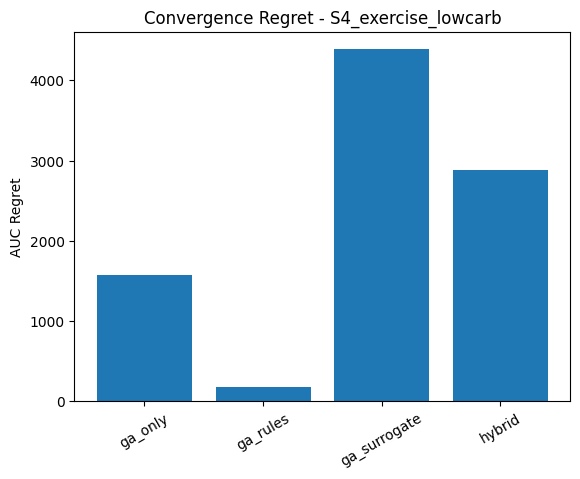

In [ ]:
subset = df_csv[df_csv["Scenario"] == "S4_exercise_lowcarb"].copy()

plt.figure()
plt.bar(subset["Method"], subset["AUCregret"])
plt.title("Convergence Regret - S4_exercise_lowcarb")
plt.ylabel("AUC Regret")
plt.xticks(rotation=30)
plt.show()

In [ ]:
#CELL 11 — Export LaTeX
latex_table = summary.to_latex(index=False, float_format="%.2f")
print(latex_table)

\begin{tabular}{llrrrrr}
\toprule
Scenario & Method & Fitness & TIR & TBR & TAR & SevereHypo \\
\midrule
S1_normal & GA+Rules & 99.79 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & GA+Surrogate & 99.79 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & GA-only & 99.79 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & Hybrid & 99.81 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA+Rules & 99.68 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA+Surrogate & 99.62 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA-only & 99.72 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & Hybrid & 99.66 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA+Rules & 99.53 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA+Surrogate & 99.50 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA-only & 99.67 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & Hybrid & 99.58 & 100.00 & 0.00 & 0.00 & 0 \\
S4_exercise_lowcarb & GA+Rules & 99.14 & 100.00 & 0.00 & 0.00 & 0 \\
S4_exercise_lowcarb & GA+Surrogate & 99.38 & 100.00 & 0.00 & 0.00 & 0 \\
S4